In [1]:
import os
import torch
import numpy as np
from matplotlib import pyplot as plt
from wavediffusion.wavedata import npyDataResized
from torch.utils.data import DataLoader
from wavediffusion.model import Scaled
from wavediffusion.model_unet import myUnet
from wavediffusion.diffusion import ScheduleLogLinear, ScheduleDDPM, samples, samples_thres
from accelerate import Accelerator
from torch_ema import ExponentialMovingAverage as EMA
from torchvision import transforms as tf

%load_ext autoreload
%autoreload 2

## Checking climatology of a particular month

In [26]:
file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/stokes_global/'
year = 2012
file_names = [(f'wave_{year:04d}{i:02d}.npy') for i in range(1, 13)]

arrays = []

for fname in file_names:
    arr = np.load(os.path.join(file_path, fname))
    arrays.append(arr[:, 0, :, :])

hs = np.concatenate(arrays, axis=0)

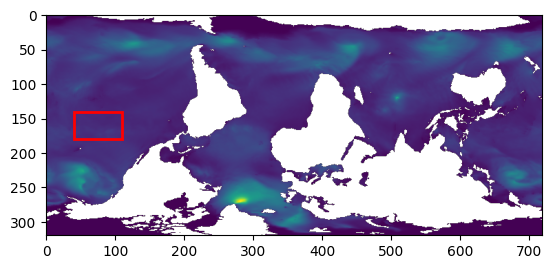

In [34]:
import matplotlib.patches as patches

# Example array
A = hs[0]

# Selected ranges
row_min, row_max = 140, 180     # rows
col_min, col_max = 40, 110    # columns

fig, ax = plt.subplots()
im = ax.imshow(A, origin="upper")
rect = patches.Rectangle((col_min, row_min), col_max - col_min, row_max - row_min, linewidth=2, edgecolor='red', facecolor='none')

ax.add_patch(rect); plt.show()

In [49]:
import pandas as pd
hs_trop = hs[:,row_min:row_max,col_min:col_max]
time = pd.date_range(
    start="2012-01-01",
    periods=2928,
    freq="3H" 
)
s = pd.Series(hs_trop.mean(axis=(1,2)), index=time)
monthly_std = s.groupby(s.index.month).std()

/tmp/ipykernel_4799/1919799526.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time = pd.date_range(


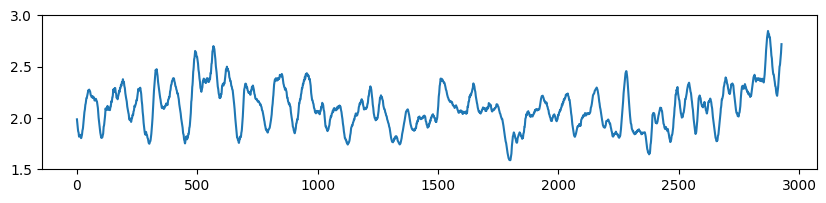

In [56]:
fig = plt.figure(figsize=[10,2])
plt.plot(hs_trop.mean(axis=(1,2)))
plt.ylim([1.5,3])
plt.show()

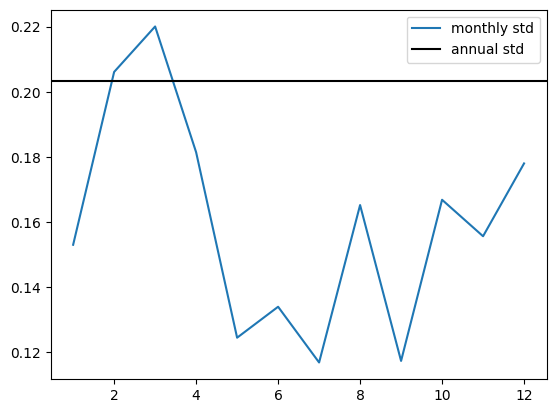

In [58]:
plt.plot(monthly_std, label='monthly std')
plt.axhline(s.std(), c = 'k', label='annual std')
plt.legend()

### Construct test month

In [59]:
file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/stokes_global/'
month = 3
file_names = [(f'wave_{i:04d}{month:02d}', f'forcing_{i:04d}{month:02d}') for i in range(2012,2013)]

file_list = [(os.path.join(file_path, f'{x}.npy'), 
              os.path.join(file_path, f'{f}.npy')) for x, f in file_names]   
# data = npyDataResized(
#     file_list,
#     resize_x=(320,320), resize_f=(320,320), 
#     landmaskname=os.path.join(file_path, 'mask.npy'),
#     use_icymask=True, compute_stats=True,
#     OPTION=2
# )

stats_file = os.path.join(file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'][[0,4,5]], stats['stdx'][[0,4,5]]
meanf, stdf = stats['meanf'], stats['stdf']
data = npyDataResized(
    file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=2
)

print('Computing climatological maps...')
meanx, stdx, meanf, stdf = data.compute_clim_map()

Computing climatological maps...


### Load model

In [61]:
RESUME = True
epoch = 8
path = '/global/homes/j/jiarongw/scratch_folder/log1p/stokes1/'
weights_file = path + f'ckpt_{epoch}.pt'

model = Scaled(myUnet)(in_dim=320, in_ch=3, out_ch=3, ch=192, precond_ch=3, 
                       scale=(torch.tensor([0.,0.,0.,]), torch.tensor([0.,0.,0.,]),
                              torch.tensor([0.,0.,0.,]), torch.tensor([0.,0.,0.,])),
                       ch_mult=(1, 2, 2), attn_resolutions=(16,))

ema = EMA(model.parameters(), decay=0.999)
if RESUME:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])

pytorch_total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {pytorch_total_params}")
pytorch_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {pytorch_trainable_params}")

Total Parameters: 55144515
Total Trainable Parameters: 55144515


In [62]:
### Helper function
def invert_x_bc_hw(data, x, mask):
    """ x:    (B, C, H, W), mask: (B, Hm, Wm) or (B, 1, Hm, Wm) """
    B = x.shape[0]
    x_out = []
    for b in range(B):
        # invert single sample
        xb = data.invert_x(x[b])          # (C, H, W)
        xb = xb * tf.Resize((320,720))(mask[b].to(x))
        x_out.append(xb)
    return torch.stack(x_out, dim=0)

### Generate (or load from file)

In [63]:
GUIDED = False
batch_size = 2
schedule_infer = ScheduleDDPM(N=700)
a = Accelerator()
loader = DataLoader(data, batch_size=batch_size, shuffle=False)
model, loader = a.prepare(model, loader)
ema.to(a.device)
model.eval()

myUnetScaled(
  (sig_embed): SigmaEmbedderSinCos(
    (mlp): Sequential(
      (0): Linear(in_features=2, out_features=768, bias=True)
      (1): SiLU()
      (2): Linear(in_features=768, out_features=768, bias=True)
    )
  )
  (conv_in): Conv2d(6, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): Module(
      (blocks): ModuleList(
        (0-1): 2 x CondSequential(
          (0): ResnetBlock(
            (layer1): Sequential(
              (0): GroupNorm(32, 192, eps=1e-06, affine=True)
              (1): SiLU()
              (2): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            )
            (temb_proj): Sequential(
              (0): SiLU()
              (1): Linear(in_features=768, out_features=192, bias=True)
            )
            (layer2): Sequential(
              (0): GroupNorm(32, 192, eps=1e-06, affine=True)
              (1): SiLU()
              (2): Dropout(p=0.1, inplace=False)
              (3): C

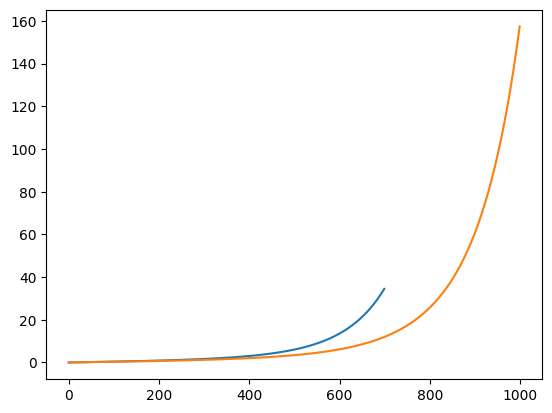

In [34]:
schedule_infer = ScheduleDDPM(N=700)
plt.plot(schedule_infer.sigmas)
schedule_infer = ScheduleDDPM(N=1000)
plt.plot(schedule_infer.sigmas)

In [64]:
%%time
# x_sampled = np.zeros((len(loader), 4, 320, 720))
with torch.no_grad():
    x_sampled = []
    with ema.average_parameters():
        for i, (x, f, mask) in enumerate(loader):
            print(f'Generating batch {i} ...')
            if GUIDED:
                hs_thres = -data.meanx[0]/data.stdx[0]
                *xt, x0 = samples_thres(model, schedule_infer.sample_sigmas(100), gam=1, mu=0.5, batchsize=x.shape[0], 
                                        thres=hs_thres, accelerator=a, cond=f, mask=mask)
            else:
                *xt, x0 = samples(model, schedule_infer.sample_sigmas(100), gam=1, mu=0.5, batchsize=x.shape[0],
                                  accelerator=a, cond=f, mask=mask)
    
            ##### TODO: Make this inversion batch wise!
            x_ = invert_x_bc_hw(data, x0, mask)
            # x_sampled[i] = x_.cpu().numpy().mean(axis=0)
            x_sampled.extend(x_.cpu().numpy())

/global/u1/j/jiarongw/wavediffusion/src/wavediffusion/wavedata.py:221: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /mscratch/sd/s/swowner/pytorch-build/pytorch/2.6.0/pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  f = torch.from_numpy(self.F_files[file_idx][local_idx]).float()


Generating batch 0 ...
Generating batch 1 ...
Generating batch 2 ...
Generating batch 3 ...
Generating batch 4 ...
Generating batch 5 ...
Generating batch 6 ...
Generating batch 7 ...
Generating batch 8 ...
Generating batch 9 ...
Generating batch 10 ...
Generating batch 11 ...
Generating batch 12 ...
Generating batch 13 ...
Generating batch 14 ...
Generating batch 15 ...
Generating batch 16 ...
Generating batch 17 ...
Generating batch 18 ...
Generating batch 19 ...
Generating batch 20 ...
Generating batch 21 ...
Generating batch 22 ...
Generating batch 23 ...
Generating batch 24 ...
Generating batch 25 ...
Generating batch 26 ...
Generating batch 27 ...
Generating batch 28 ...
Generating batch 29 ...
Generating batch 30 ...
Generating batch 31 ...
Generating batch 32 ...
Generating batch 33 ...
Generating batch 34 ...
Generating batch 35 ...
Generating batch 36 ...
Generating batch 37 ...
Generating batch 38 ...
Generating batch 39 ...
Generating batch 40 ...
Generating batch 41 ...
Ge

In [65]:
x_sampled = np.array(x_sampled)
np.save('temp/sampled_stokes_march.npy', x_sampled)

In [66]:
x_sampled = np.load('temp/sampled_stokes_march.npy')
meanx_sampled = np.average(x_sampled, axis=0)
stdx_sampled = np.std(x_sampled, axis=0)

### Generating videos

#### Sampled

In [ ]:
for i in range(0, x_sampled.shape[0]):    
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    img0 = axes[0].imshow(x_sampled[i][0,::-1], vmin=0, vmax=10, cmap='Blues')
    img1 = axes[1].imshow(x_sampled[i][1,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
    img2 = axes[2].imshow(x_sampled[i][2,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
    plt.colorbar(img0, ax=axes[0], fraction=0.02, pad=0.04)
    plt.colorbar(img1, ax=axes[1], fraction=0.02, pad=0.04)
    plt.colorbar(img2, ax=axes[2], fraction=0.02, pad=0.04)
    axes[0].set_title('Significant Wave Height (m)')
    axes[1].set_title('Stokes drift u (m/s)')
    axes[2].set_title('Stokes drift v (m/s)')
    plt.savefig(f'temp/plots/sample{i}.png')
    plt.close(fig)

#### Truth

In [20]:
for i in range(0, x_sampled.shape[0]):
    x, f, mask = data.__getitem__(i)
    x_ = data.invert_x(x)
    x_truth = x_ * tf.Resize((320,720))(mask.to(x_))
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))
    img0 = axes[0,0].imshow(x_truth.cpu().numpy()[0,::-1], vmin=0, vmax=10, cmap='Blues')
    img1 = axes[0,1].imshow(x_truth.cpu().numpy()[1,::-1], vmin=0, vmax=300, cmap='Reds')
    img2 = axes[1,0].imshow(x_truth.cpu().numpy()[2,::-1], vmin=0, vmax=360, cmap='twilight_r')
    img3 = axes[1,1].imshow(x_truth.cpu().numpy()[3,::-1], vmin=0, vmax=90, cmap='Greys')
    plt.savefig(f'temp/plots/truth{i}.png')
    plt.close(fig)

### Visualize stats

#### Generated

#### Truth

/tmp/ipykernel_4799/1583565221.py:32: RuntimeWarning: divide by zero encountered in divide
  img0 = axes[3,0].imshow((meanx[0,::-1] - meanx_sampled[0,::-1])/meanx[0,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
/tmp/ipykernel_4799/1583565221.py:32: RuntimeWarning: invalid value encountered in divide
  img0 = axes[3,0].imshow((meanx[0,::-1] - meanx_sampled[0,::-1])/meanx[0,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
/tmp/ipykernel_4799/1583565221.py:33: RuntimeWarning: divide by zero encountered in divide
  img1 = axes[3,1].imshow((meanx[4,::-1] - meanx_sampled[1,::-1])/meanx[4,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
/tmp/ipykernel_4799/1583565221.py:33: RuntimeWarning: invalid value encountered in divide
  img1 = axes[3,1].imshow((meanx[4,::-1] - meanx_sampled[1,::-1])/meanx[4,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
/tmp/ipykernel_4799/1583565221.py:34: RuntimeWarning: divide by zero encountered in divide
  img2 = axes[3,2].imshow((meanx[5,::-1] - meanx_sampled[2,::-1])/meanx[5,::-1]

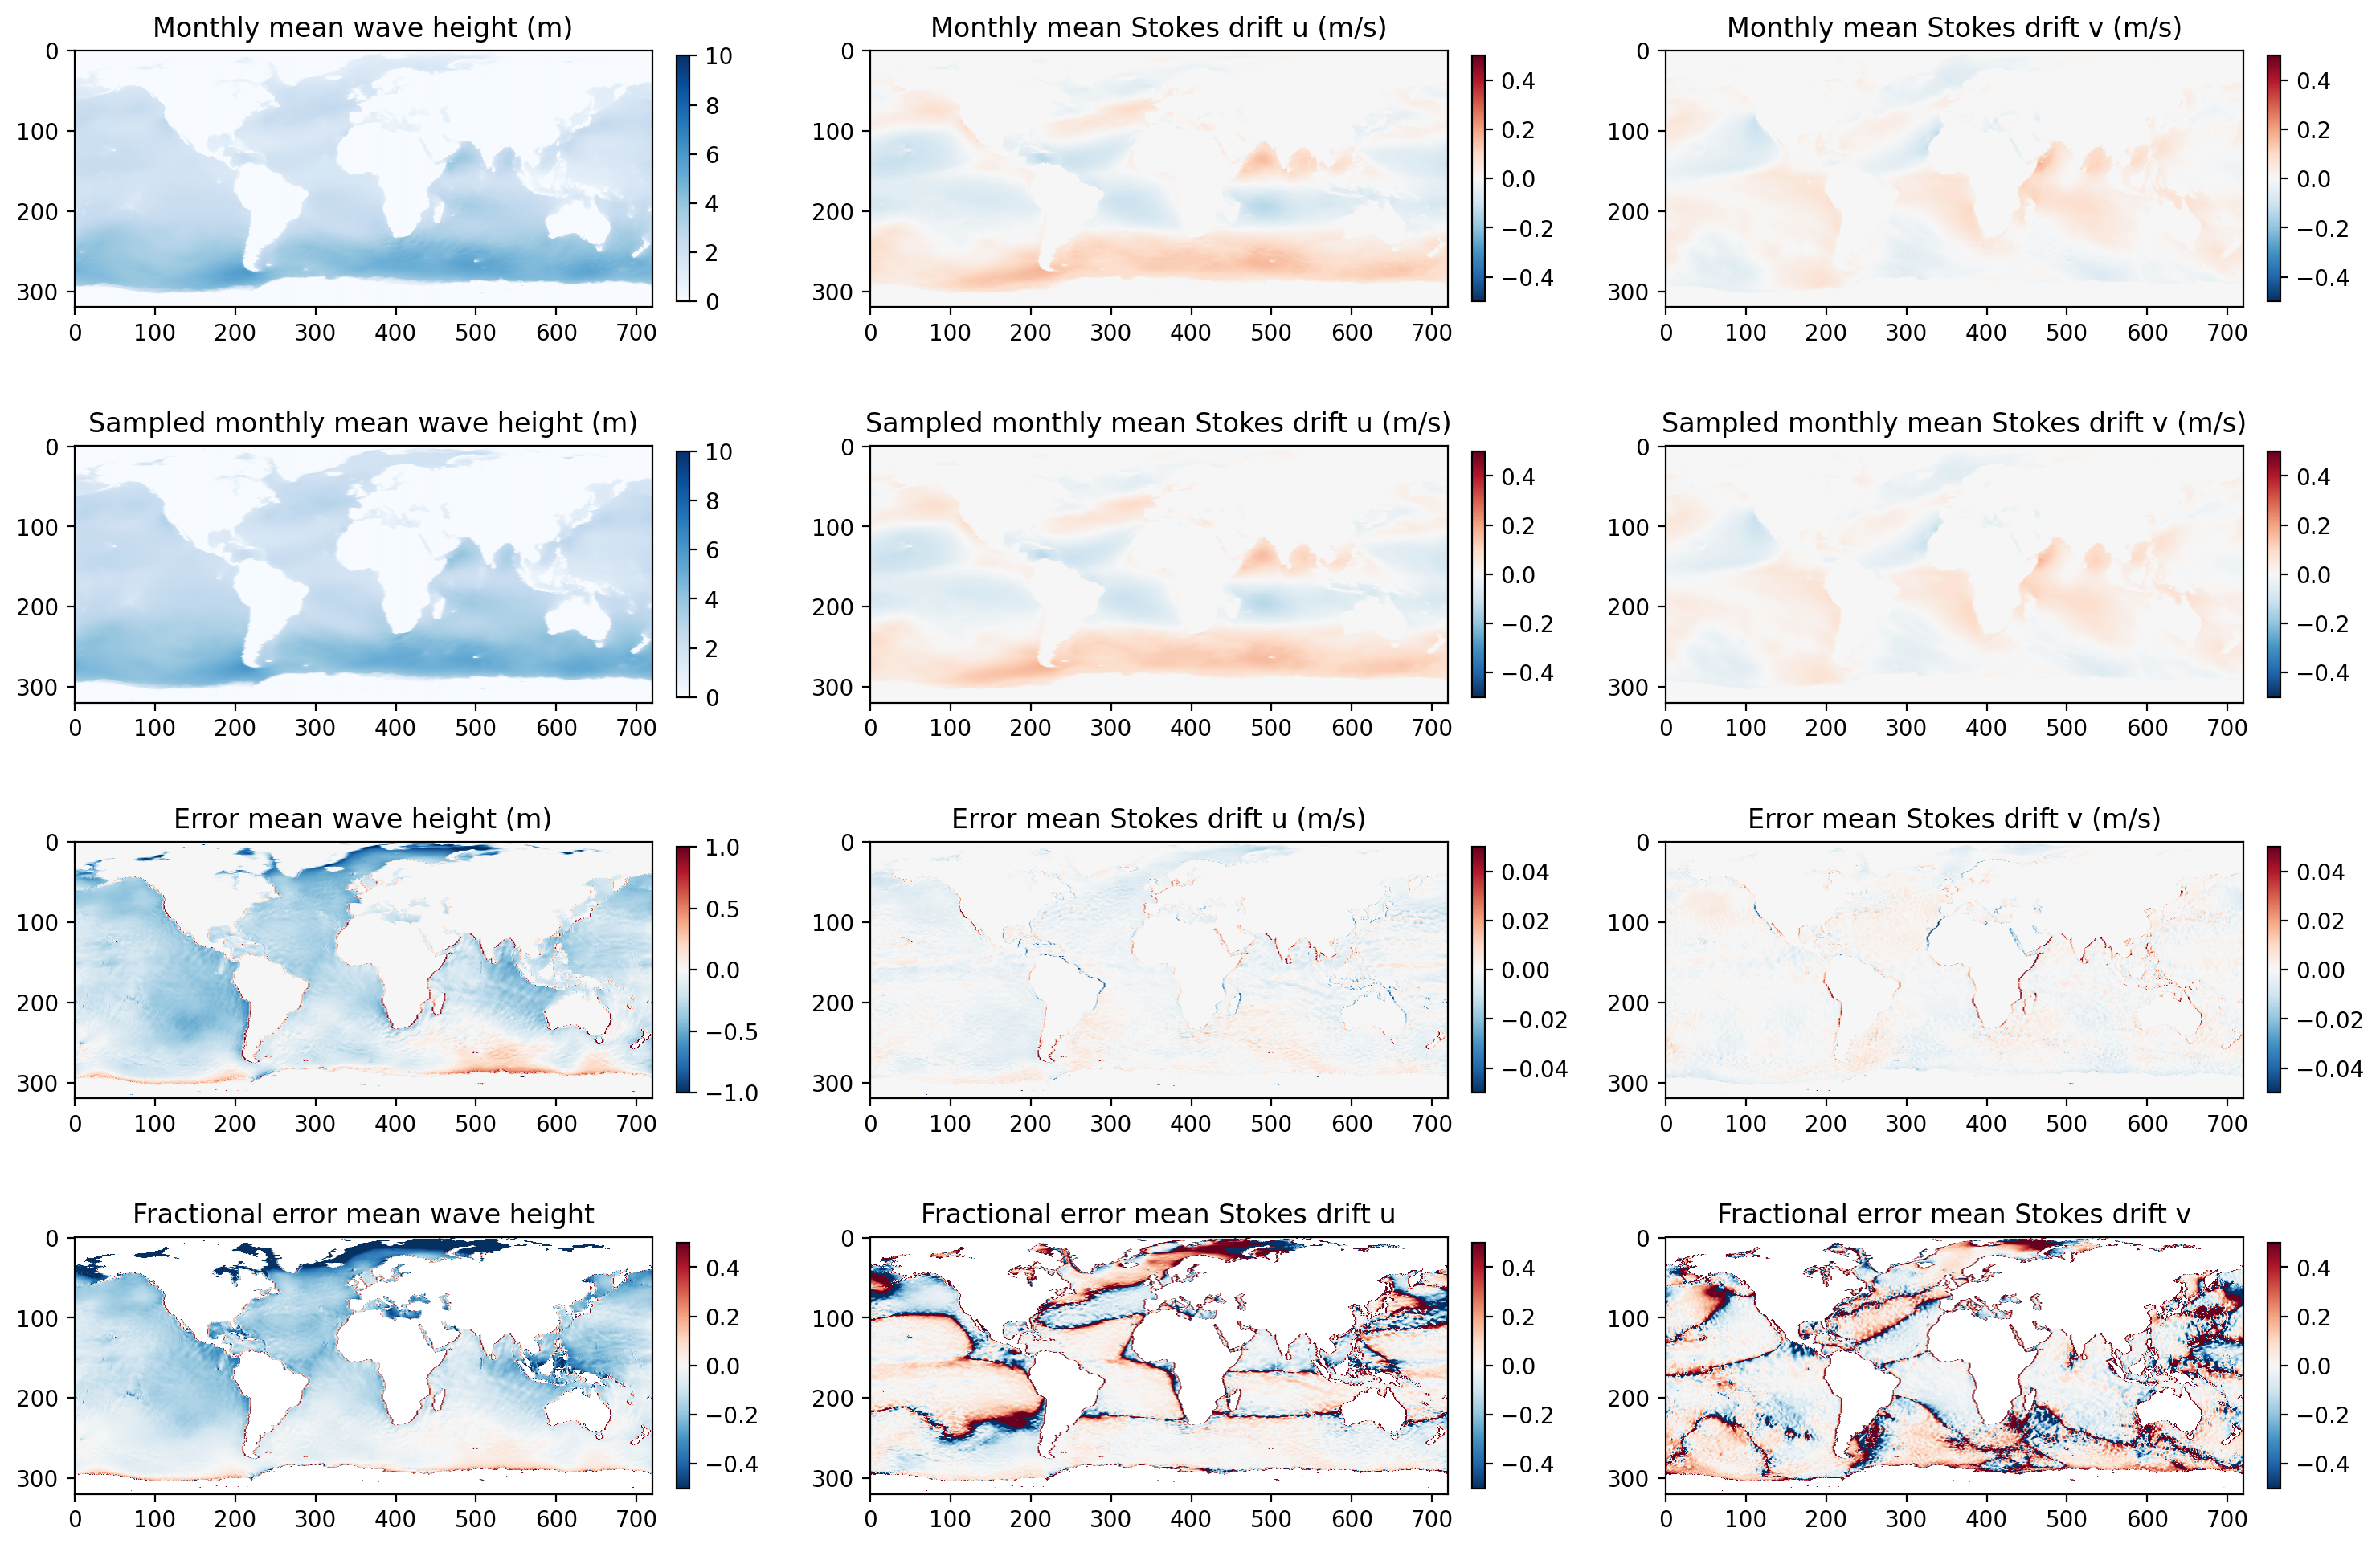

In [22]:
fig, axes = plt.subplots(4, 3, figsize=(15, 10), dpi=200)
img0 = axes[0,0].imshow(meanx[0,::-1], vmin=0, vmax=10, cmap='Blues')
img1 = axes[0,1].imshow(meanx[4,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
img2 = axes[0,2].imshow(meanx[5,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[0,2], fraction=0.02, pad=0.04)
axes[0,0].set_title('Monthly mean wave height (m)')
axes[0,1].set_title('Monthly mean Stokes drift u (m/s)')
axes[0,2].set_title('Monthly mean Stokes drift v (m/s)')

img0 = axes[1,0].imshow(meanx_sampled[0,::-1], vmin=0, vmax=10, cmap='Blues')
img1 = axes[1,1].imshow(meanx_sampled[1,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
img2 = axes[1,2].imshow(meanx_sampled[2,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
plt.colorbar(img0, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[1,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,2], fraction=0.02, pad=0.04)
axes[1,0].set_title('Sampled monthly mean wave height (m)')
axes[1,1].set_title('Sampled monthly mean Stokes drift u (m/s)')
axes[1,2].set_title('Sampled monthly mean Stokes drift v (m/s)')

img0 = axes[2,0].imshow((meanx[0,::-1] - meanx_sampled[0,::-1]), vmin=-1, vmax=1, cmap='RdBu_r')
img1 = axes[2,1].imshow((meanx[4,::-1] - meanx_sampled[1,::-1]), vmin=-0.05, vmax=0.05, cmap='RdBu_r')
img2 = axes[2,2].imshow((meanx[5,::-1] - meanx_sampled[2,::-1]), vmin=-0.05, vmax=0.05, cmap='RdBu_r')
plt.colorbar(img0, ax=axes[2,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[2,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[2,2], fraction=0.02, pad=0.04)
axes[2,0].set_title('Error mean wave height (m)')
axes[2,1].set_title('Error mean Stokes drift u (m/s)')
axes[2,2].set_title('Error mean Stokes drift v (m/s)')

img0 = axes[3,0].imshow((meanx[0,::-1] - meanx_sampled[0,::-1])/meanx[0,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
img1 = axes[3,1].imshow((meanx[4,::-1] - meanx_sampled[1,::-1])/meanx[4,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
img2 = axes[3,2].imshow((meanx[5,::-1] - meanx_sampled[2,::-1])/meanx[5,::-1], vmin=-0.5, vmax=0.5, cmap='RdBu_r')
plt.colorbar(img0, ax=axes[3,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[3,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[3,2], fraction=0.02, pad=0.04)
axes[3,0].set_title('Fractional error mean wave height')
axes[3,1].set_title('Fractional error mean Stokes drift u')
axes[3,2].set_title('Fractional error mean Stokes drift v')

plt.tight_layout()


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4799/4179160056.py:18: SyntaxWarning: invalid escape sequence '\s'
  axes[1,0].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ wave height (m)')
/tmp/ipykernel_4799/4179160056.py:19: SyntaxWarning: invalid escape sequence '\s'
  axes[1,1].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ Stokes drift u (m/s)')
/tmp/ipykernel_4799/4179160056.py:20: SyntaxWarning: invalid escape sequence '\s'
  axes[1,2].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ Stokes drift v (m/s)')
/tmp/ipykernel_4799/4179160056.py:22: RuntimeWarning: divide by zero encountered in divide
  img0 = axes[2,0].imshow(stdx_sampled[0,::-1]/stdx[0,::-1] - 1, vmin=-0.5, vmax

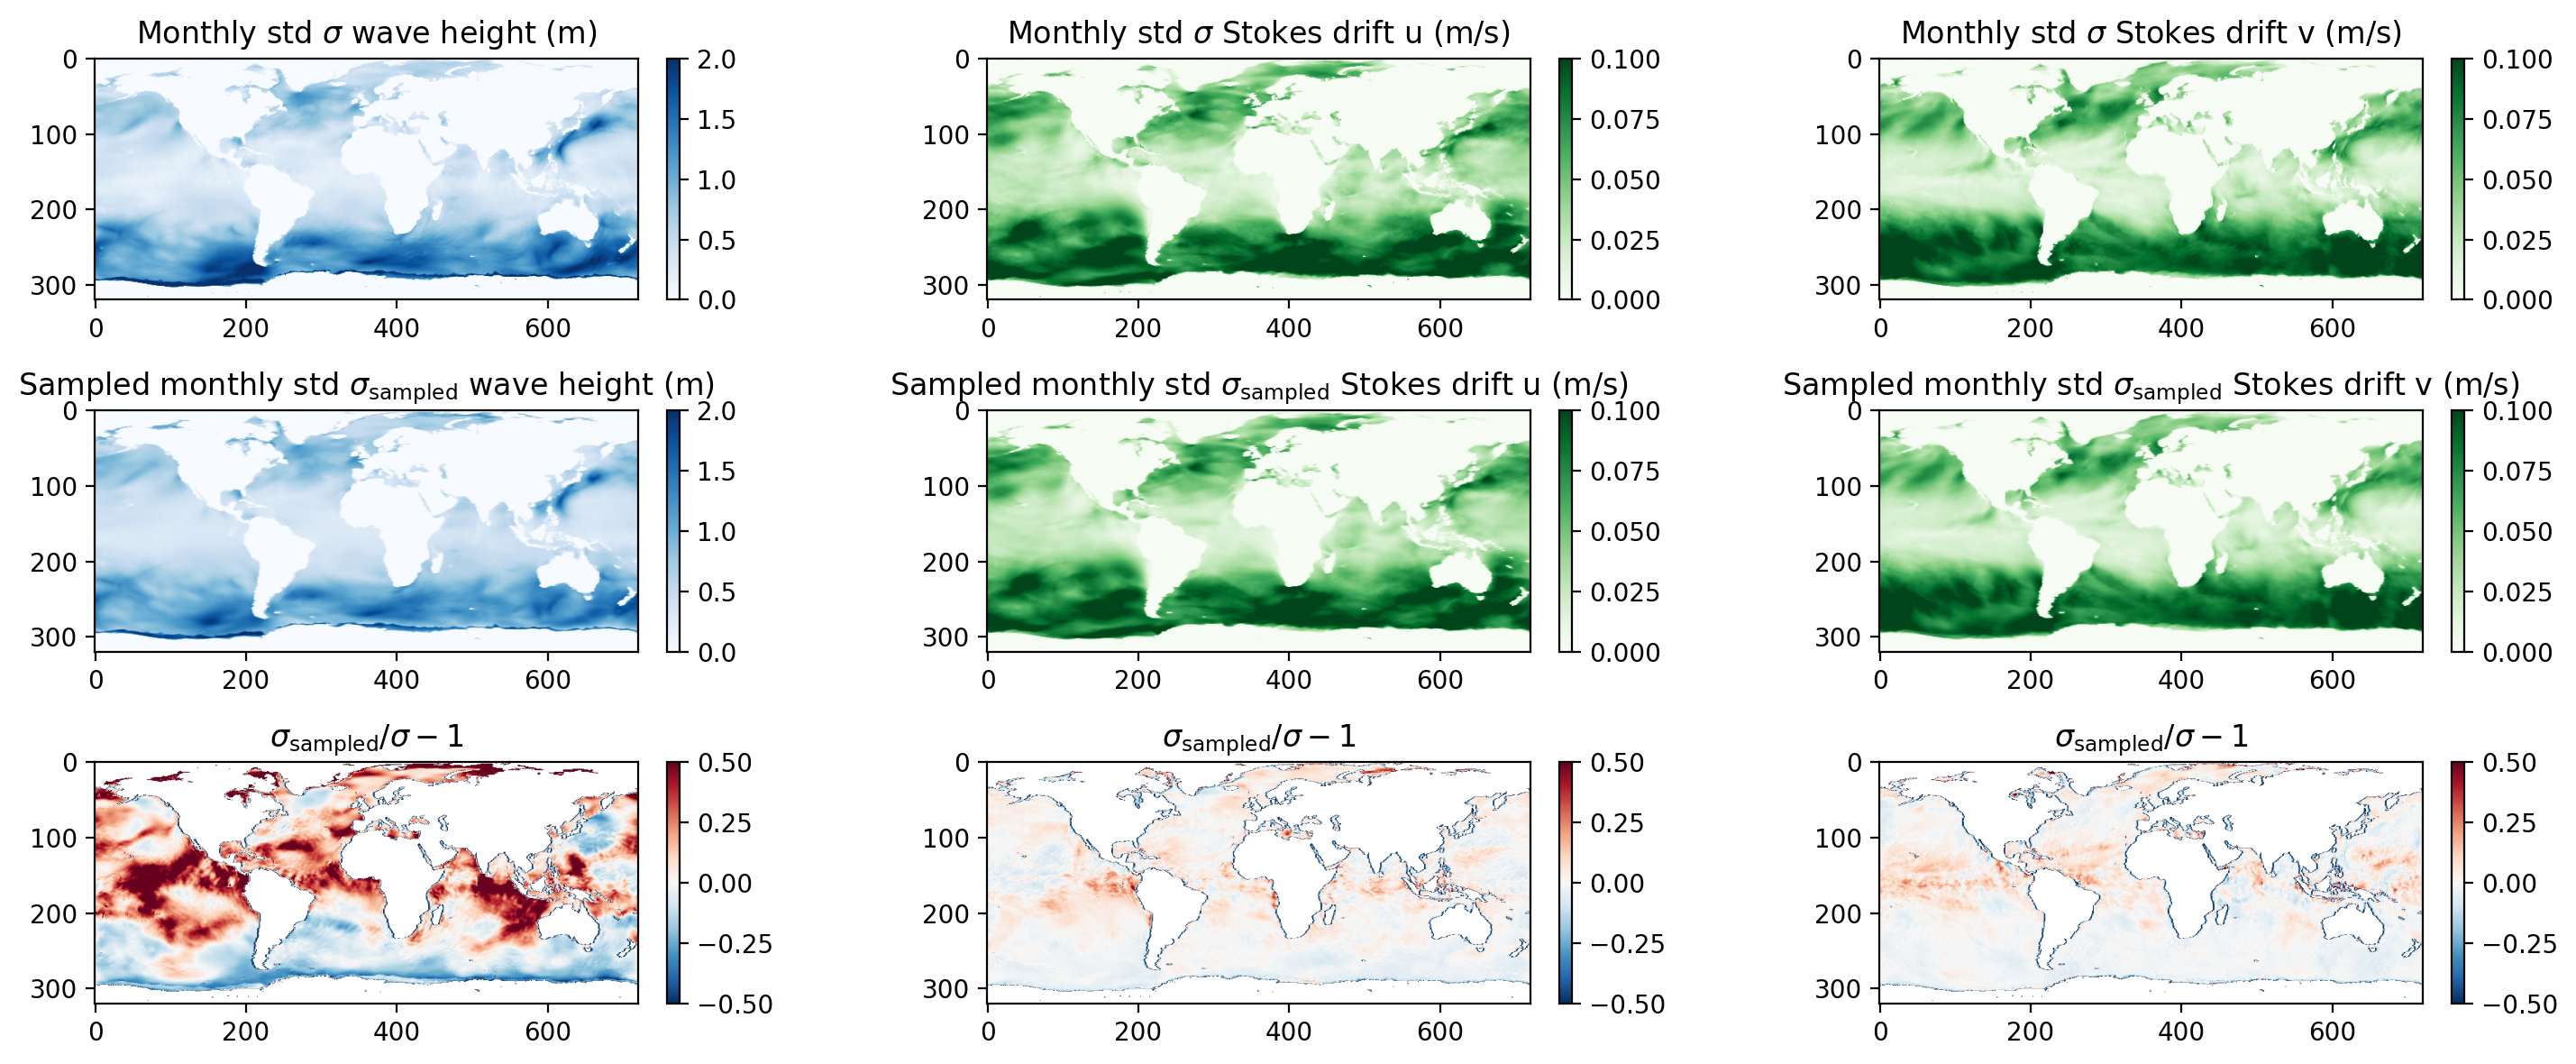

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(15, 6), dpi=200)
img0 = axes[0,0].imshow(stdx[0,::-1], vmin=0, vmax=2, cmap='Blues')
img1 = axes[0,1].imshow(stdx[4,::-1], vmin=0, vmax=0.1, cmap='Greens')
img2 = axes[0,2].imshow(stdx[5,::-1], vmin=0, vmax=0.1, cmap='Greens')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[0,2], fraction=0.02, pad=0.04)
axes[0,0].set_title(r'Monthly std $\sigma$ wave height (m)')
axes[0,1].set_title(r'Monthly std $\sigma$ Stokes drift u (m/s)')
axes[0,2].set_title(r'Monthly std $\sigma$ Stokes drift v (m/s)')

img0 = axes[1,0].imshow(stdx_sampled[0,::-1], vmin=0, vmax=2, cmap='Blues')
img1 = axes[1,1].imshow(stdx_sampled[1,::-1], vmin=0, vmax=0.1, cmap='Greens')
img2 = axes[1,2].imshow(stdx_sampled[2,::-1], vmin=0, vmax=0.1, cmap='Greens')
plt.colorbar(img0, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[1,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,2], fraction=0.02, pad=0.04)
axes[1,0].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ wave height (m)')
axes[1,1].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ Stokes drift u (m/s)')
axes[1,2].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ Stokes drift v (m/s)')

img0 = axes[2,0].imshow(stdx_sampled[0,::-1]/stdx[0,::-1] - 1, vmin=-0.5, vmax=0.5, cmap='RdBu_r')
img1 = axes[2,1].imshow(stdx_sampled[1,::-1]/stdx[4,::-1] - 1, vmin=-0.5, vmax=0.5, cmap='RdBu_r')
img2 = axes[2,2].imshow(stdx_sampled[2,::-1]/stdx[5,::-1] - 1, vmin=-0.5, vmax=0.5, cmap='RdBu_r')
plt.colorbar(img0, ax=axes[2,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[2,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[2,2], fraction=0.02, pad=0.04)
axes[2,0].set_title(r'$\sigma_{\mathrm{sampled}} / \sigma - 1$')
axes[2,1].set_title(r'$\sigma_{\mathrm{sampled}} / \sigma - 1$')
axes[2,2].set_title(r'$\sigma_{\mathrm{sampled}} / \sigma - 1$')

plt.tight_layout()


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4799/4179160056.py:18: SyntaxWarning: invalid escape sequence '\s'
  axes[1,0].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ wave height (m)')
/tmp/ipykernel_4799/4179160056.py:19: SyntaxWarning: invalid escape sequence '\s'
  axes[1,1].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ Stokes drift u (m/s)')
/tmp/ipykernel_4799/4179160056.py:20: SyntaxWarning: invalid escape sequence '\s'
  axes[1,2].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ Stokes drift v (m/s)')
/tmp/ipykernel_4799/4179160056.py:22: RuntimeWarning: divide by zero encountered in divide
  img0 = axes[2,0].imshow(stdx_sampled[0,::-1]/stdx[0,::-1] - 1, vmin=-0.5, vmax

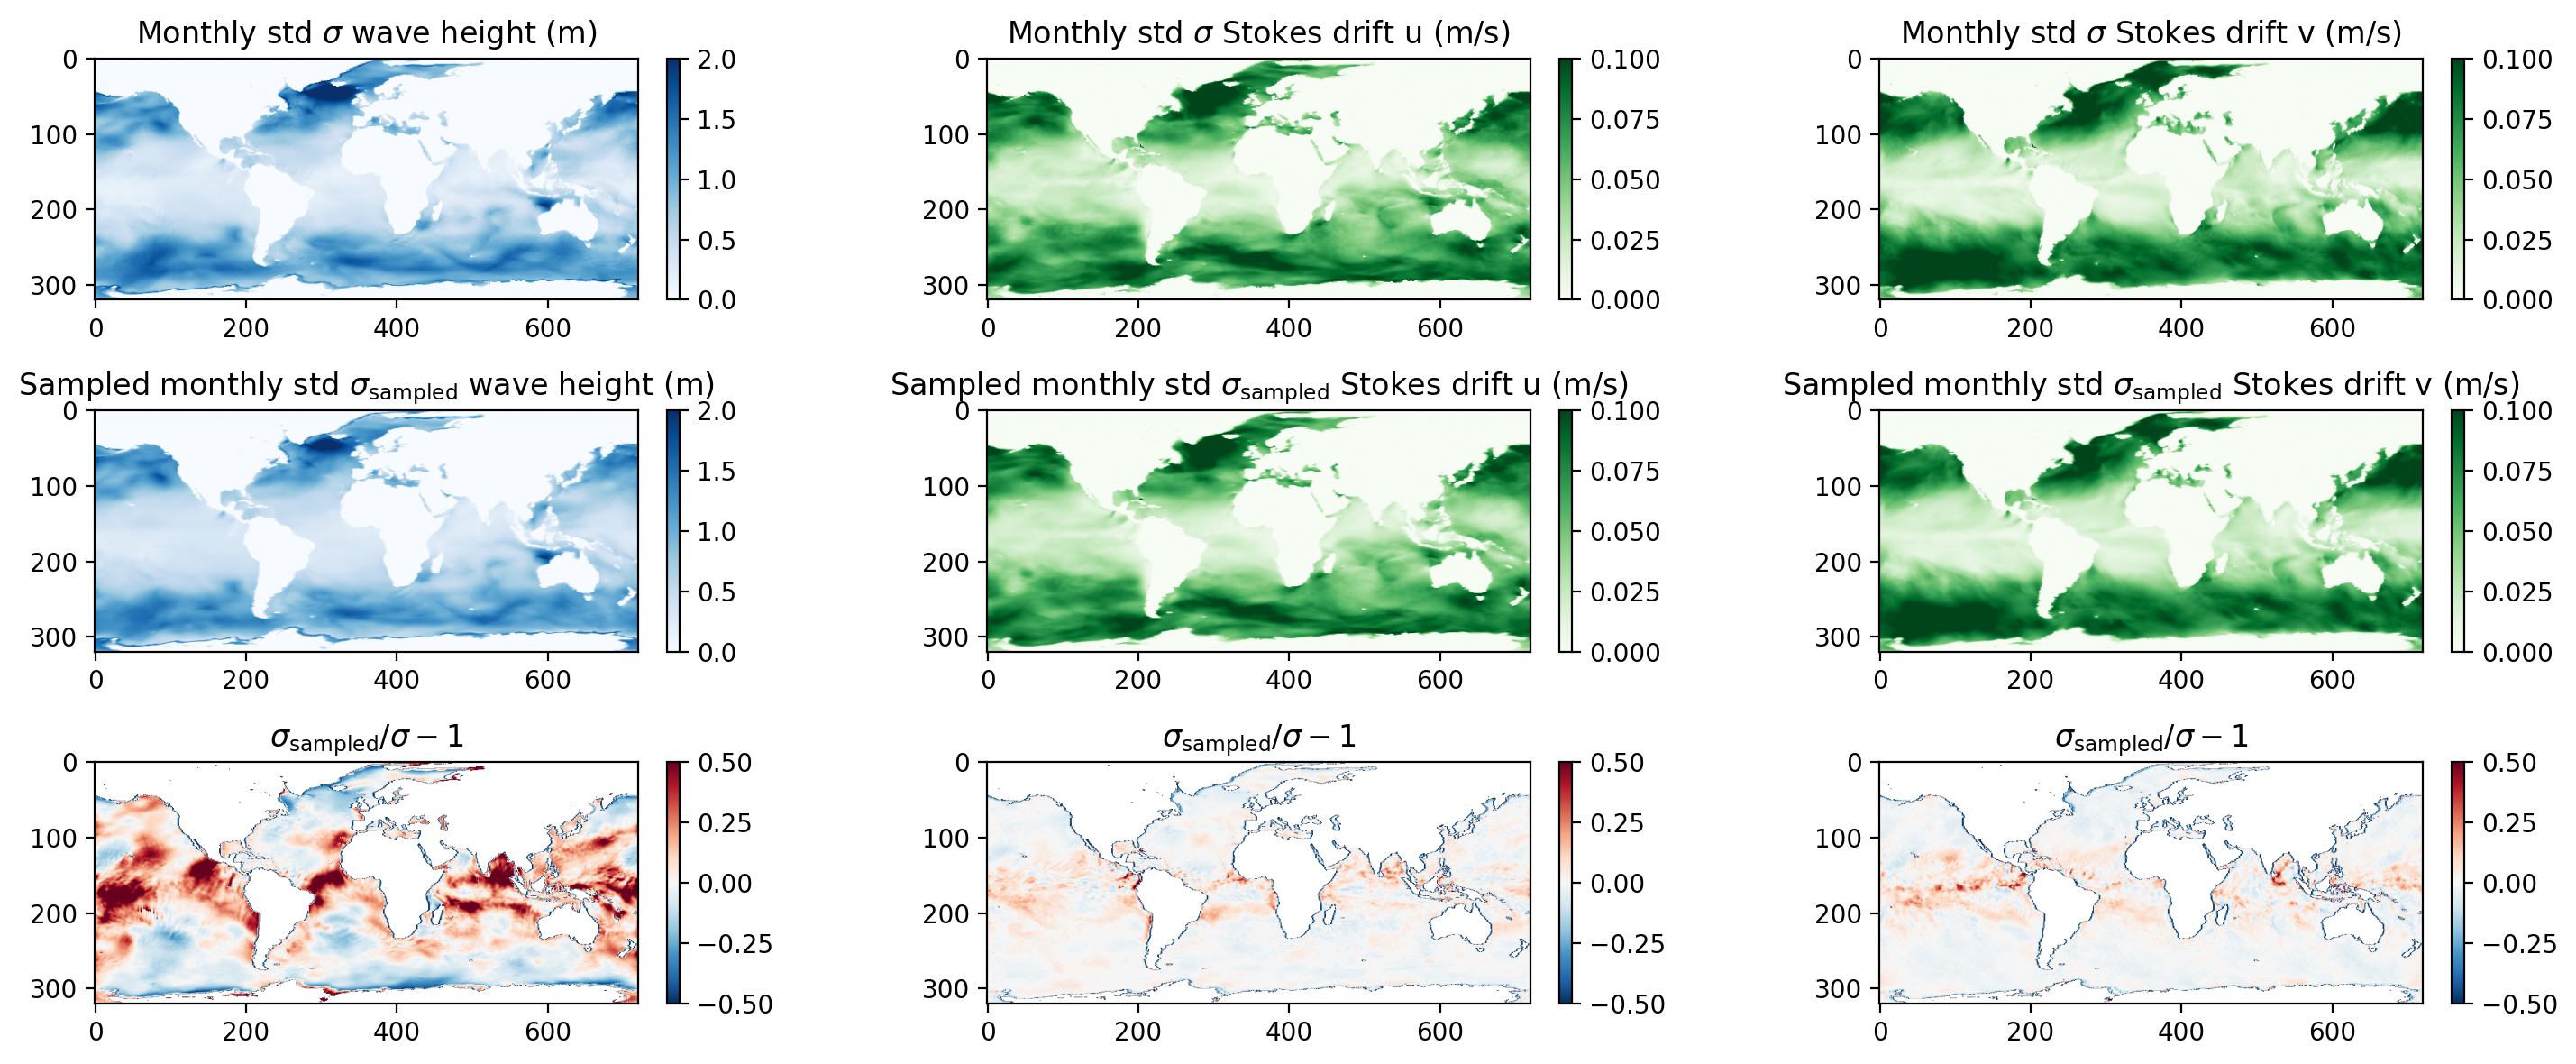

In [67]:
fig, axes = plt.subplots(3, 3, figsize=(15, 6), dpi=200)
img0 = axes[0,0].imshow(stdx[0,::-1], vmin=0, vmax=2, cmap='Blues')
img1 = axes[0,1].imshow(stdx[4,::-1], vmin=0, vmax=0.1, cmap='Greens')
img2 = axes[0,2].imshow(stdx[5,::-1], vmin=0, vmax=0.1, cmap='Greens')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[0,2], fraction=0.02, pad=0.04)
axes[0,0].set_title(r'Monthly std $\sigma$ wave height (m)')
axes[0,1].set_title(r'Monthly std $\sigma$ Stokes drift u (m/s)')
axes[0,2].set_title(r'Monthly std $\sigma$ Stokes drift v (m/s)')

img0 = axes[1,0].imshow(stdx_sampled[0,::-1], vmin=0, vmax=2, cmap='Blues')
img1 = axes[1,1].imshow(stdx_sampled[1,::-1], vmin=0, vmax=0.1, cmap='Greens')
img2 = axes[1,2].imshow(stdx_sampled[2,::-1], vmin=0, vmax=0.1, cmap='Greens')
plt.colorbar(img0, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[1,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,2], fraction=0.02, pad=0.04)
axes[1,0].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ wave height (m)')
axes[1,1].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ Stokes drift u (m/s)')
axes[1,2].set_title('Sampled monthly std $\sigma_{\mathrm{sampled}}$ Stokes drift v (m/s)')

img0 = axes[2,0].imshow(stdx_sampled[0,::-1]/stdx[0,::-1] - 1, vmin=-0.5, vmax=0.5, cmap='RdBu_r')
img1 = axes[2,1].imshow(stdx_sampled[1,::-1]/stdx[4,::-1] - 1, vmin=-0.5, vmax=0.5, cmap='RdBu_r')
img2 = axes[2,2].imshow(stdx_sampled[2,::-1]/stdx[5,::-1] - 1, vmin=-0.5, vmax=0.5, cmap='RdBu_r')
plt.colorbar(img0, ax=axes[2,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[2,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[2,2], fraction=0.02, pad=0.04)
axes[2,0].set_title(r'$\sigma_{\mathrm{sampled}} / \sigma - 1$')
axes[2,1].set_title(r'$\sigma_{\mathrm{sampled}} / \sigma - 1$')
axes[2,2].set_title(r'$\sigma_{\mathrm{sampled}} / \sigma - 1$')

plt.tight_layout()
